# Graph-Based Fraud Detection

Objective:
- Model electricity network as a graph
- Detect suspicious clusters
- Compute graph-based risk scores
- Enhance fraud detection using network intelligence

In [8]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("../data/processed/final_model_ready_dataset.csv")
mapping = pd.read_csv("../data/graph_data/consumer_transformer_mapping.csv")

df.head()

,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,transformer_id,total_kwh,temperature,...,transformer_deviation,is_peak_hour,rolling_max_24h,rolling_min_24h,sudden_drop_flag,isolation_anomaly_flag,isolation_score,lof_anomaly_flag,optimized_iso_flag,theft_probability
0,1,2024-01-01 00:00:00,1.408501,231.134680,6.600922,0.970170,0,T7,46.629769,25.086067,...,-0.008255,0,1.408501,1.408501,0,1,0.010488,0,1,7.873644e-06
1,1,2024-01-01 01:00:00,1.590901,226.709743,6.022453,0.949561,0,T7,49.026706,25.086067,...,-0.006012,0,1.590901,1.408501,0,0,-0.009386,0,0,3.358269e-07
2,1,2024-01-01 02:00:00,1.539829,233.289587,6.373323,0.967279,0,T7,50.220320,25.086067,...,-0.007800,0,1.590901,1.408501,0,0,-0.007120,0,0,3.575445e-07
3,1,2024-01-01 03:00:00,1.215253,233.507623,5.297672,0.879270,0,T7,53.799312,25.086067,...,-0.015873,0,1.590901,1.215253,0,0,-0.005006,0,0,1.350626e-06
4,1,2024-01-01 04:00:00,2.131333,231.189122,8.212522,0.987504,0,T7,54.309090,25.086067,...,0.000783,0,2.131333,1.215253,0,1,0.014058,1,1,1.115324e-06


In [10]:
G = nx.Graph()

# Add transformer nodes
transformers = mapping["transformer_id"].unique()
G.add_nodes_from(transformers, node_type="transformer")

# Add consumer nodes and edges
for _, row in mapping.iterrows():
    consumer = f"C{row['consumer_id']}"
    transformer = row["transformer_id"]

    G.add_node(consumer, node_type="consumer")
    G.add_edge(consumer, transformer)

print("Total Nodes:", G.number_of_nodes())
print("Total Edges:", G.number_of_edges())

Total Nodes: 210
Total Edges: 200


In [11]:
degree_centrality = nx.degree_centrality(G)

# Extract only consumer nodes
consumer_centrality = {
    node: centrality
    for node, centrality in degree_centrality.items()
    if str(node).startswith("C")
}

centrality_df = pd.DataFrame.from_dict(
    consumer_centrality,
    orient="index",
    columns=["degree_centrality"]
)

centrality_df.head()

,degree_centrality
C1,0.004785
C2,0.004785
C3,0.004785
C4,0.004785
C5,0.004785


In [12]:
centrality_df["consumer_id"] = centrality_df.index.str.replace("C", "").astype(int)

df = df.merge(
    centrality_df[["consumer_id", "degree_centrality"]],
    on="consumer_id",
    how="left"
)

df.head()

,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,transformer_id,total_kwh,temperature,...,is_peak_hour,rolling_max_24h,rolling_min_24h,sudden_drop_flag,isolation_anomaly_flag,isolation_score,lof_anomaly_flag,optimized_iso_flag,theft_probability,degree_centrality
0,1,2024-01-01 00:00:00,1.408501,231.134680,6.600922,0.970170,0,T7,46.629769,25.086067,...,0,1.408501,1.408501,0,1,0.010488,0,1,7.873644e-06,0.004785
1,1,2024-01-01 01:00:00,1.590901,226.709743,6.022453,0.949561,0,T7,49.026706,25.086067,...,0,1.590901,1.408501,0,0,-0.009386,0,0,3.358269e-07,0.004785
2,1,2024-01-01 02:00:00,1.539829,233.289587,6.373323,0.967279,0,T7,50.220320,25.086067,...,0,1.590901,1.408501,0,0,-0.007120,0,0,3.575445e-07,0.004785
3,1,2024-01-01 03:00:00,1.215253,233.507623,5.297672,0.879270,0,T7,53.799312,25.086067,...,0,1.590901,1.215253,0,0,-0.005006,0,0,1.350626e-06,0.004785
4,1,2024-01-01 04:00:00,2.131333,231.189122,8.212522,0.987504,0,T7,54.309090,25.086067,...,0,2.131333,1.215253,0,1,0.014058,1,1,1.115324e-06,0.004785


In [13]:
# Create theft summary per transformer
theft_ratio = (
    df.groupby("transformer_id")["theft_label"]
    .mean()
    .reset_index()
    .rename(columns={"theft_label": "transformer_theft_ratio"})
)

df = df.merge(
    theft_ratio,
    on="transformer_id",
    how="left"
)

df.head()

,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,transformer_id,total_kwh,temperature,...,rolling_max_24h,rolling_min_24h,sudden_drop_flag,isolation_anomaly_flag,isolation_score,lof_anomaly_flag,optimized_iso_flag,theft_probability,degree_centrality,transformer_theft_ratio
0,1,2024-01-01 00:00:00,1.408501,231.134680,6.600922,0.970170,0,T7,46.629769,25.086067,...,1.408501,1.408501,0,1,0.010488,0,1,7.873644e-06,0.004785,0.00195
1,1,2024-01-01 01:00:00,1.590901,226.709743,6.022453,0.949561,0,T7,49.026706,25.086067,...,1.590901,1.408501,0,0,-0.009386,0,0,3.358269e-07,0.004785,0.00195
2,1,2024-01-01 02:00:00,1.539829,233.289587,6.373323,0.967279,0,T7,50.220320,25.086067,...,1.590901,1.408501,0,0,-0.007120,0,0,3.575445e-07,0.004785,0.00195
3,1,2024-01-01 03:00:00,1.215253,233.507623,5.297672,0.879270,0,T7,53.799312,25.086067,...,1.590901,1.215253,0,0,-0.005006,0,0,1.350626e-06,0.004785,0.00195
4,1,2024-01-01 04:00:00,2.131333,231.189122,8.212522,0.987504,0,T7,54.309090,25.086067,...,2.131333,1.215253,0,1,0.014058,1,1,1.115324e-06,0.004785,0.00195


In [14]:
# Graph-based suspicion score
df["graph_suspicion_score"] = (
    0.6 * df["transformer_theft_ratio"] +
    0.4 * df["degree_centrality"]
)

df.head()

,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,transformer_id,total_kwh,temperature,...,rolling_min_24h,sudden_drop_flag,isolation_anomaly_flag,isolation_score,lof_anomaly_flag,optimized_iso_flag,theft_probability,degree_centrality,transformer_theft_ratio,graph_suspicion_score
0,1,2024-01-01 00:00:00,1.408501,231.134680,6.600922,0.970170,0,T7,46.629769,25.086067,...,1.408501,0,1,0.010488,0,1,7.873644e-06,0.004785,0.00195,0.003084
1,1,2024-01-01 01:00:00,1.590901,226.709743,6.022453,0.949561,0,T7,49.026706,25.086067,...,1.408501,0,0,-0.009386,0,0,3.358269e-07,0.004785,0.00195,0.003084
2,1,2024-01-01 02:00:00,1.539829,233.289587,6.373323,0.967279,0,T7,50.220320,25.086067,...,1.408501,0,0,-0.007120,0,0,3.575445e-07,0.004785,0.00195,0.003084
3,1,2024-01-01 03:00:00,1.215253,233.507623,5.297672,0.879270,0,T7,53.799312,25.086067,...,1.215253,0,0,-0.005006,0,0,1.350626e-06,0.004785,0.00195,0.003084
4,1,2024-01-01 04:00:00,2.131333,231.189122,8.212522,0.987504,0,T7,54.309090,25.086067,...,1.215253,0,1,0.014058,1,1,1.115324e-06,0.004785,0.00195,0.003084


In [15]:
# Identify high-risk transformers
high_risk_transformers = theft_ratio[
    theft_ratio["transformer_theft_ratio"] > 0.1
]["transformer_id"].tolist()

print("High Risk Transformers:")
print(high_risk_transformers)

High Risk Transformers:
[]


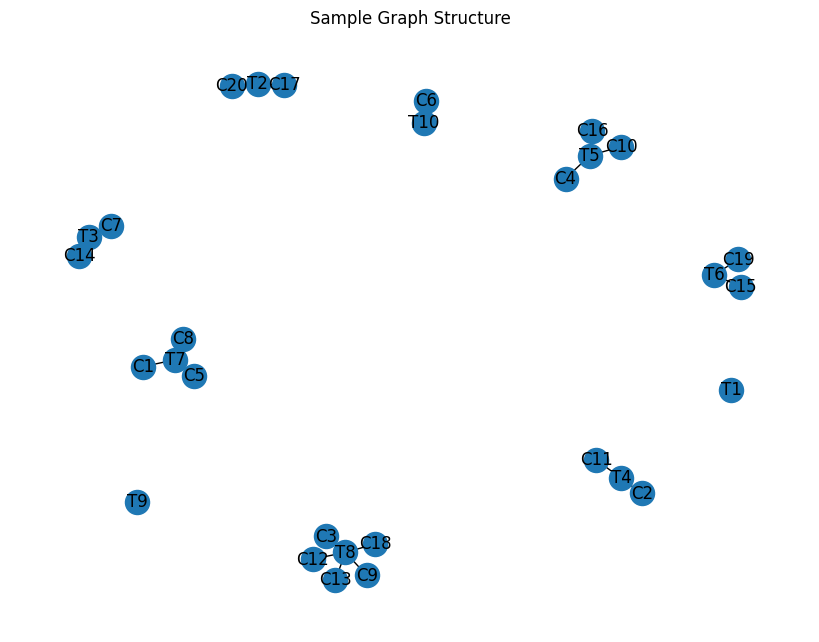

In [16]:
plt.figure(figsize=(8,6))

sub_nodes = list(G.nodes())[:30]
subgraph = G.subgraph(sub_nodes)

nx.draw(subgraph, with_labels=True, node_size=300)
plt.title("Sample Graph Structure")
plt.show()

In [17]:
corr = df[["graph_suspicion_score", "theft_label"]].corr()

print("Correlation with Theft:")
print(corr)

Correlation with Theft:
                       graph_suspicion_score  theft_label
graph_suspicion_score               1.000000     0.042329
theft_label                         0.042329     1.000000


In [18]:
df.to_csv("../data/processed/final_dataset_with_graph.csv", index=False)

print("Graph-enhanced dataset saved.")

Graph-enhanced dataset saved.


## Graph-Based Fraud Detection Summary

1. Modeled electricity network as bipartite graph.
2. Calculated consumer centrality.
3. Measured transformer-level theft ratio.
4. Generated graph suspicion score.
5. Identified high-risk transformer clusters.

Graph intelligence enhances:
- Fraud ring detection
- Coordinated theft patterns
- Transformer-level anomaly detection

Next Step:
- Combine Graph Score + ML Probability
- Build Ensemble Risk Model